# web_agent — Kaggle driver (hybrid)

Stable core (`labels`, `config`, `dataset`, `model`, `loss`, `metrics`) lives in the
`web_agent` package, cloned from GitHub. Orchestration + analysis (training loop,
eval, plots, error inspection, result images) lives **here in the notebook** so you
can watch every step.

Workflow: edit package in IDE → push to GitHub `Code` → **Pull** here → re-run.

In [18]:
# 1. Clone the package + install VLM deps, make it importable via sys.path (re-run safe)
#
# We do NOT `pip install -e .` — the PEP 660 editable install registers a
# meta-path finder that shadows sub-packages (web_agent.data). Plain sys.path is
# reliable. Qwen2.5-VL needs a recent transformers + bitsandbytes + accelerate.
import os, sys
REPO = "https://github.com/Kiyas-Mahmud/webagent.git"
ROOT = "/kaggle/working/webagent"
SRC = f"{ROOT}/src"
if not os.path.isdir(ROOT):
    !git clone -b Code {REPO} {ROOT}
else:
    !cd {ROOT} && git pull --ff-only
%cd {ROOT}

# Qwen2.5-VL classes need transformers >= 4.49; 4-bit needs bitsandbytes+accelerate.
!pip install -q -U "transformers>=4.49" bitsandbytes accelerate

# Drop any stale cached web_agent and point imports at the fresh src/ tree.
for m in [k for k in list(sys.modules) if k == "web_agent" or k.startswith("web_agent.")]:
    del sys.modules[m]
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import web_agent
from web_agent.data import verify_dataset  # prove subpackage import works
print("web_agent ready ->", list(web_agent.__path__))

remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 8 (delta 5), reused 8 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 1.53 KiB | 58.00 KiB/s, done.
From https://github.com/Kiyas-Mahmud/webagent
   4e0e050..109d9c2  Code       -> origin/Code
Updating 4e0e050..109d9c2
Fast-forward
 notebooks/kaggle_train.ipynb     |  2 +-
 src/web_agent/data/dataloader.py | 12 +++++++++---
 2 files changed, 10 insertions(+), 4 deletions(-)
/kaggle/working/webagent
web_agent ready -> ['/kaggle/working/webagent/src/web_agent']


In [19]:
# 2. Confirm GPU + dataset path, then verify the dataset (Phase 1, in-kernel)
import os
from pathlib import Path
!nvidia-smi -L
print("input dirs:", os.listdir("/kaggle/input"))

DATA_PATH = "/kaggle/input/datasets/kiyasmahmud/thesisdata/FinalData"
assert os.path.isdir(DATA_PATH), f"fix DATA_PATH; not found: {DATA_PATH}"

from web_agent.data.verify_dataset import verify
report = verify(Path(DATA_PATH))
print(report.text())
assert report.ok, "dataset verification FAILED — read the report above"

GPU 0: Tesla T4 (UUID: GPU-c02713ac-15d0-2b3d-66c7-c302b959be4e)
GPU 1: Tesla T4 (UUID: GPU-f6108575-c029-b8dd-add5-ceedd3686a7c)
input dirs: ['datasets']
DATASET VERIFICATION REPORT

=== 1.1 Integrity ===
  [PASS] train count == 38,875  ->  38875
  [PASS] total == 70,965  ->  70965
  [INFO] val / test counts  ->  16070 / 16020
  [PASS] all 24 fields present in every record
  [PASS] no empty state_before / state_after
  [PASS] ZERO original_task_id overlap train vs val/test  ->  0 shared
  [PASS] train split field all 'train'
  [PASS] val/test splits are eval sub-splits only

=== 1.2 Label distributions (train) ===
  [PASS] outcome ~72% FAILURE  ->  71.9% FAILURE
  [INFO] failure_type  ->  {'PERCEPTION_ERROR': 9929, 'ACTION_MISMATCH': 14992, 'NONE': 10934, 'LOOP_DETECTED': 3020}
  [PASS] action_type only CLICK/TYPE/SELECT  ->  {'SELECT', 'CLICK', 'TYPE'}
  [INFO] recovery_strategy  ->  {'RETRY': 12752, 'REPLAN': 8182, 'NONE': 10934, 'BACKTRACK': 6810, 'ALTERNATIVE_TARGET': 197}

=== 1.

In [20]:
# 3. Phase 2/3 — Qwen2.5-VL processor + one VLM batch (joint image+text)
from transformers import AutoProcessor
from web_agent.config import load_config
from web_agent.utils.seed import set_seed
from web_agent.data.dataloader import load_split, build_dataloader

set_seed(42)
cfg = load_config("configs/backbones/qwen25vl_3b.yaml")
cfg["data"]["root"] = DATA_PATH
cfg["data"]["num_workers"] = 0          # VLM processor: avoid worker pickling overhead

bb = cfg["backbone"]
processor = AutoProcessor.from_pretrained(
    bb["vlm_model"], min_pixels=bb["min_pixels"], max_pixels=bb["max_pixels"],
)

train = load_split(cfg, "train")
loader = build_dataloader(cfg, mode="full_labels", records=train,
                          processor=processor, tokenizer=None,
                          limit=cfg["stages"]["smoke"],
                          batch_size=cfg["optim"]["batch_size"])

batch = next(iter(loader))
print("batch keys:", list(batch.keys()))
for k, v in batch.items():
    print(f"  {k:18} {tuple(v.shape)}  {v.dtype}")

batch keys: ['bbox', 'bbox_mask', 'borrowed', 'label_outcome', 'label_failtype', 'label_action', 'label_recovery', 'label_memory', 'label_confidence', 'input_ids', 'attention_mask', 'pixel_values', 'image_grid_thw']
  bbox               (2, 4)  torch.float32
  bbox_mask          (2, 1)  torch.float32
  borrowed           (2, 1)  torch.float32
  label_outcome      (2,)  torch.int64
  label_failtype     (2,)  torch.int64
  label_action       (2,)  torch.int64
  label_recovery     (2,)  torch.int64
  label_memory       (2, 1)  torch.float32
  label_confidence   (2, 1)  torch.float32
  input_ids          (2, 276)  torch.int64
  attention_mask     (2, 276)  torch.int64
  pixel_values       (1512, 1176)  torch.float32
  image_grid_thw     (2, 3)  torch.int64


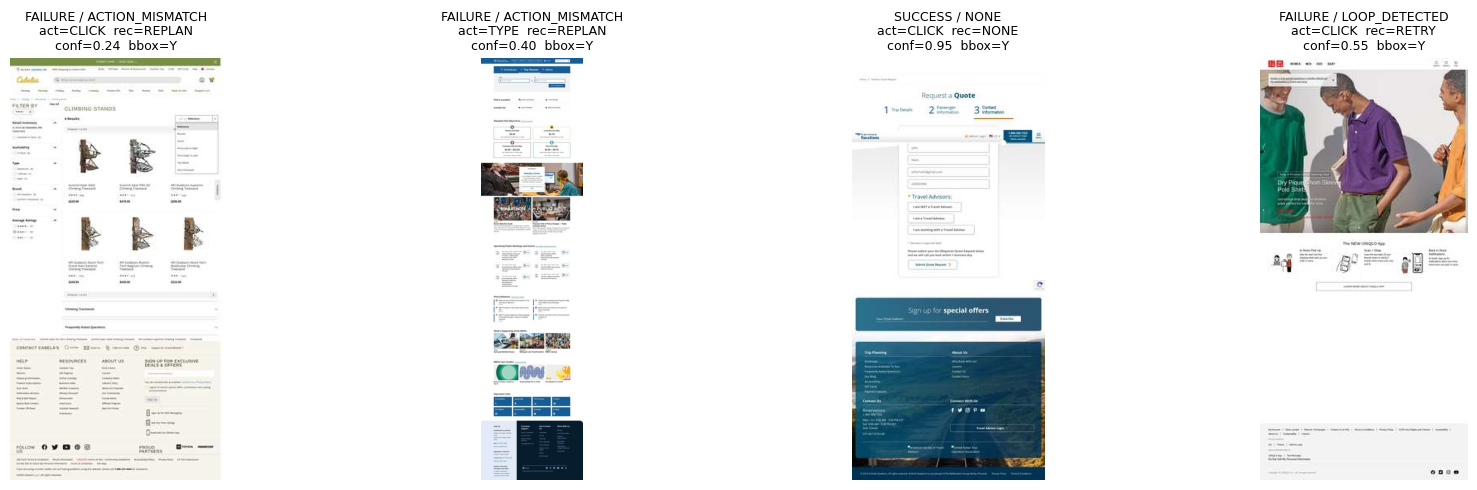

encoded label_outcome : [1, 0]
encoded label_action  : [0, 0]
bbox_mask             : [1.0, 1.0]


In [9]:
# 4. Visual sanity-check — show 4 raw screenshots with their decoded labels
import matplotlib.pyplot as plt
from PIL import Image
from web_agent.labels import (
    EXECUTION_OUTCOME_INV, FAILURE_TYPE_INV, ACTION_TYPE_INV, RECOVERY_STRATEGY_INV,
)

rows = loader.dataset.records[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, rec in zip(axes, rows):
    ax.imshow(Image.open(f"{DATA_PATH}/{rec['state_before']}").convert("RGB"))
    ax.axis("off")
    ax.set_title(
        f"{rec['execution_outcome']} / {rec['failure_type']}\n"
        f"act={rec['action_type']}  rec={rec['recovery_strategy']}\n"
        f"conf={rec['agent_confidence_before']:.2f}  bbox={'Y' if rec['action_target_bbox'] else 'N'}",
        fontsize=9,
    )
plt.tight_layout(); plt.show()

# Confirm encoded labels match the strings above
print("encoded label_outcome :", batch["label_outcome"][:4].tolist())
print("encoded label_action  :", batch["label_action"][:4].tolist())
print("bbox_mask             :", batch["bbox_mask"][:4].squeeze(-1).tolist())

In [21]:
# 5. Phase 3 — build the model (Qwen2.5-VL-3B 4-bit + adapter + 3 heads)
import torch
from web_agent.models.model import WebAgentModel
from web_agent.models.loss import CombinedLoss

model = WebAgentModel(cfg)                  # loads Qwen in 4-bit (downloads ~3-4GB first run)
print("VLM hidden dim D =", model.encoder.hidden_dim, "-> adapter -> 768")

# The 4-bit VLM is placed on GPU by device_map; move adapter + heads to it too.
device = "cuda"
for m in (model.adapter, model.failure_head, model.action_head, model.memory_head):
    m.to(device)

n_train = sum(p.numel() for p in model.trainable_parameters())
n_total = sum(p.numel() for p in model.parameters())
print(f"trainable (adapter+heads): {n_train:,}   total: {n_total:,}")
loss_fn = CombinedLoss(cfg).to(device)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

VLM hidden dim D = 2048 -> adapter -> 768
trainable (adapter+heads): 2,171,677   total: 2,036,196,125


In [22]:
# 6. SMOKE TEST (16 rows) — forward -> combined loss -> backward -> one optimizer step
opt = torch.optim.AdamW(model.trainable_parameters(),
                        lr=cfg["phases"]["warmup"]["lr_heads"])
model.train()

w_before = next(iter(model.adapter.parameters())).detach().clone()

batch = next(iter(loader))
preds = model(batch)                         # VLMEncoder moves its own inputs to GPU
targets = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
terms = loss_fn(preds, targets)

print("loss terms:", {k: round(v.detach().item(), 4) for k, v in terms.items()})
assert torch.isfinite(terms["total"]), "loss is NaN/inf - STOP and fix"

terms["total"].backward()
opt.step()

w_after = next(iter(model.adapter.parameters())).detach()
changed = not torch.equal(w_before, w_after)
print("adapter weight changed:", changed)
print("peak GPU mem (GB):", round(torch.cuda.max_memory_allocated() / 1e9, 2))
print("SMOKE RESULT:", "PASS" if (torch.isfinite(terms["total"]) and changed) else "FAIL")

loss terms: {'outcome': 0.5161, 'failtype': 1.6719, 'action': 1.2641, 'recovery': 1.7387, 'bbox': 0.1565, 'memory': 0.7601, 'confidence': 0.0295, 'total': 0.9611}
adapter weight changed: True
peak GPU mem (GB): 10.57
SMOKE RESULT: PASS


In [23]:
# 7. MINI TRAIN — prove the loss DROPS (subset, frozen VLM, train adapter+heads)
import time
from web_agent.utils.class_weights import compute_class_weights

MINI_ROWS = 1500      # raise later once the trend looks healthy
EPOCHS    = 1
BATCH     = 16        # smoke used ~5GB, so headroom on the T4
WORKERS   = 4         # parallelize the per-sample Qwen processing (the bottleneck)

# Class weights fix the CLICK 83.6% / LOOP 7.4% imbalance (first accuracy lever).
aw, fw = compute_class_weights(train, limit=MINI_ROWS)
print("action weights :", [round(x, 2) for x in aw.tolist()])
print("failtype weights:", [round(x, 2) for x in fw.tolist()])
loss_fn = CombinedLoss(cfg, action_class_weights=aw, failtype_class_weights=fw).to(device)

mini_loader = build_dataloader(cfg, "full_labels", train, processor, tokenizer=None,
                               limit=MINI_ROWS, batch_size=BATCH, shuffle=True,
                               num_workers=WORKERS)
opt = torch.optim.AdamW(model.trainable_parameters(),
                        lr=cfg["phases"]["warmup"]["lr_heads"])
model.train()

raw, smooth, ema, step, t0 = [], [], None, 0, time.time()
for ep in range(EPOCHS):
    for batch in mini_loader:
        preds = model(batch)
        targets = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        terms = loss_fn(preds, targets)
        opt.zero_grad(); terms["total"].backward(); opt.step()
        step += 1
        l = terms["total"].detach().item()
        ema = l if ema is None else 0.9 * ema + 0.1 * l    # smoothed trend
        raw.append(l)
        if step % 5 == 0:
            smooth.append(ema)
            print(f"ep{ep} step{step:4d}  loss {l:.3f}  ema {ema:.3f}  ({time.time()-t0:.0f}s)")

# Judge by the smoothed trend (first few vs last few), not a single noisy point.
import statistics as st
start = st.mean(smooth[:3]); end = st.mean(smooth[-3:])
print(f"\nsmoothed {start:.3f} -> {end:.3f}  ::  {'LOSS DROPS ✔' if end < start else 'NO DROP ✗'}")

action weights : [0.23, 2.73, 4.0, 0.0, 0.0]
failtype weights: [0.87, 0.95, 0.65, 3.91]
ep0 step   5  loss 1.260  ema 1.778  (138s)
ep0 step  10  loss 1.358  ema 1.584  (264s)
ep0 step  15  loss 1.031  ema 1.418  (395s)
ep0 step  20  loss 1.211  ema 1.279  (526s)
ep0 step  25  loss 0.810  ema 1.173  (655s)
ep0 step  30  loss 0.804  ema 1.059  (786s)
ep0 step  35  loss 0.806  ema 1.052  (918s)
ep0 step  40  loss 0.898  ema 1.010  (1048s)
ep0 step  45  loss 0.873  ema 0.996  (1179s)
ep0 step  50  loss 0.885  ema 0.962  (1303s)


KeyboardInterrupt: 

In [24]:
# 8. Checkpoint round-trip — save trained parts, reload, confirm identical predictions
from web_agent.utils.checkpoint import save_checkpoint, load_checkpoint

CKPT = "checkpoints/qwen3b_mini.ckpt"
save_checkpoint(CKPT,
                adapter=model.adapter.state_dict(),
                failure=model.failure_head.state_dict(),
                action=model.action_head.state_dict(),
                memory=model.memory_head.state_dict(),
                config=cfg)

model.eval()
probe = next(iter(loader))
with torch.no_grad():
    before = model(probe)["outcome"].detach().cpu()

ckpt = load_checkpoint(CKPT)
model.adapter.load_state_dict(ckpt["adapter"])
model.failure_head.load_state_dict(ckpt["failure"])
model.action_head.load_state_dict(ckpt["action"])
model.memory_head.load_state_dict(ckpt["memory"])
with torch.no_grad():
    after = model(probe)["outcome"].detach().cpu()

print("checkpoint round-trip identical:", torch.allclose(before, after, atol=1e-6))

checkpoint round-trip identical: True
